# RADC Trigger Verifications
> Charaterization of multiple-trigger events

0. Record pulses via LAN?
1. Determine total pulse-width from PulseGen-parameters (is pulse-edge included in the width?)
2. Having correctly set offsets, test if triggering occurs correctly with the expected pulse-width.
3. Determine mV <-> ADC relation
4. Verify that the time-informations are correct
    - unix<->time converter
5. Calculate integral-value of pulse
    $$
    \int_P dt = \int_a^b \frac{y}{b-a} dt + \int_b^c ydt + \int_c^d \frac{-y}{d-c}dt
    $$
6. Verify correct conversion and settings of thresholds
    - Adjustments after changes in B_Time
        - init -> B_Time -> Threshold -> B_Time -> Threshold
        - init -> Threshold -> B_Time -> Threshold -> B_Time
    - $\texttt{Thresh} \approx 1/2\ \texttt{Pulse\_height}$
7. Test trigger-limits in height (fixed B_Time, Threshold):
    - smaller pulses
    - higher pulses
8. Test trigger-limits in width (fixed B_Time, Threshold):
    - thinner pulses
    - wider pulses
9. Verify integration<->threshold relation
    - (Integrated Sum) $\texttt{new\_thresh} = \texttt{old\_thresh}\cdot\texttt{newB\_Time} / \texttt{oldB\_Time}$
    - $\texttt{adc\_thresh} = \texttt{int\_thresh} / \texttt{B\_Time}$
    - Trigger-sample $s_T = s: \texttt{int\_thresh} = \int_Pdt$ (+corrections from shaper)
10. Verify Energy-calculation
    


In [2]:
from import_helper import *
list(imports())

Device config Loaded config for utrfh from "c:\Users\utrfh\WS22-23 (MA) Masterarbeit\Codes\radc-processor\notebooks\../../nd-measurement-interfaces\user_config\utrfh_config.json"


[('data_io', 'data_parser.data_io'),
 ('irrelevant_labels',
  ['Type',
   'Subsecs',
   'Channel_number',
   'Rest',
   'min',
   'max',
   'trigger_count',
   'Multiplicity',
   'Trigger_info']),
 ('meas_base_path', 'C:/Users/utrfh/WS22-23 (MA) Masterarbeit/Measurements/'),
 ('os', 'os'),
 ('pGen_pulse_class',
  'KeysightAgilent_3220A.pulse_emulation.pGen_pulse_class'),
 ('path_to_data_parser',
  'c:\\Users\\utrfh\\WS22-23 (MA) Masterarbeit\\Codes\\radc-processor\\notebooks\\..'),
 ('path_to_meas_interfaces',
  'c:\\Users\\utrfh\\WS22-23 (MA) Masterarbeit\\Codes\\radc-processor\\notebooks\\../../nd-measurement-interfaces/'),
 ('pd', 'pandas'),
 ('plotting', 'data_parser.plotting'),
 ('plt', 'matplotlib.pyplot'),
 ('pulse_emulation', 'KeysightAgilent_3220A.pulse_emulation'),
 ('pyvisa', 'pyvisa'),
 ('struct_conversion', 'data_parser.struct_conversion'),
 ('sys', 'sys'),
 ('types', 'types')]

## Verify that the time-informations are correct

> See that "Seconds" get set correctly with "SetSecond" and increment as expected in the received packages.

Trigger-Data:
- A burst of 10 Cycles with $1$ Hz.
- (W400ns, E100ns, F1Hz, A18mV, Inverted, Cycles10)
- (B33, T:default, Threshold[0]558, Trace700, Offset:adjusted.?)

Measurement 1: (1+9 Packages received)
 - A single test package for proof-of-reception.
 - FeControl.EnTime 1
 - SetSecond:1683191271.8602521

Measurement 2: (10 packages received)
 - FeControl.EnTime 1
 - SetSecond 1683192389.1203182
 - ...
 - SetSecond 1000

Measurement 3: (3 Packages received)
 - FeControl.EnClk 1
 - FeControl.EnTime 1
 - sleep 0.3
 - eval SetSecond time() # 1683192803.4864163

 Measurement 3.1: (8 Packages received)

Above first, then:
- FeControl.EnTime 0
- FeControl.EnTime 1

In [3]:
base_path = r"C:\Users\utrfh\WS22-23 (MA) Masterarbeit\RADC_testData\2023-05-04"

tdf = struct_conversion.DataFile(    
    # base_path + r"\2023-05-04_11-07-44_readout.bin" # Measurement 1
    # base_path + r"\2023-05-04_11-27-14_readout.bin.1" # Measurement 2
    # base_path + r"\2023-05-04_11-33-06_readout.bin" # Measurement 3
    base_path + r"\2023-05-04_11-33-06_readout.bin.1" # Measurement 3.1
    )
tdf = data_io.make_total_dataFrame([tdf])
tdf.drop(labels=["Rest", "Type", "Number", "Channel_number", "Multiplicity", "Trigger_info"],
         axis="columns")
tdf[["Seconds", "Subsecs"]]

,Seconds,Subsecs
0,16,37272050
1,18,37284468
2,20,37296885
3,21,37303094
4,22,37309303
5,23,37315512
6,24,37321721
7,25,37327929


$\Longrightarrow$ The Time-Information is transmitted but does not use `SetSecond` as starting point.


## Total Pulse-Width


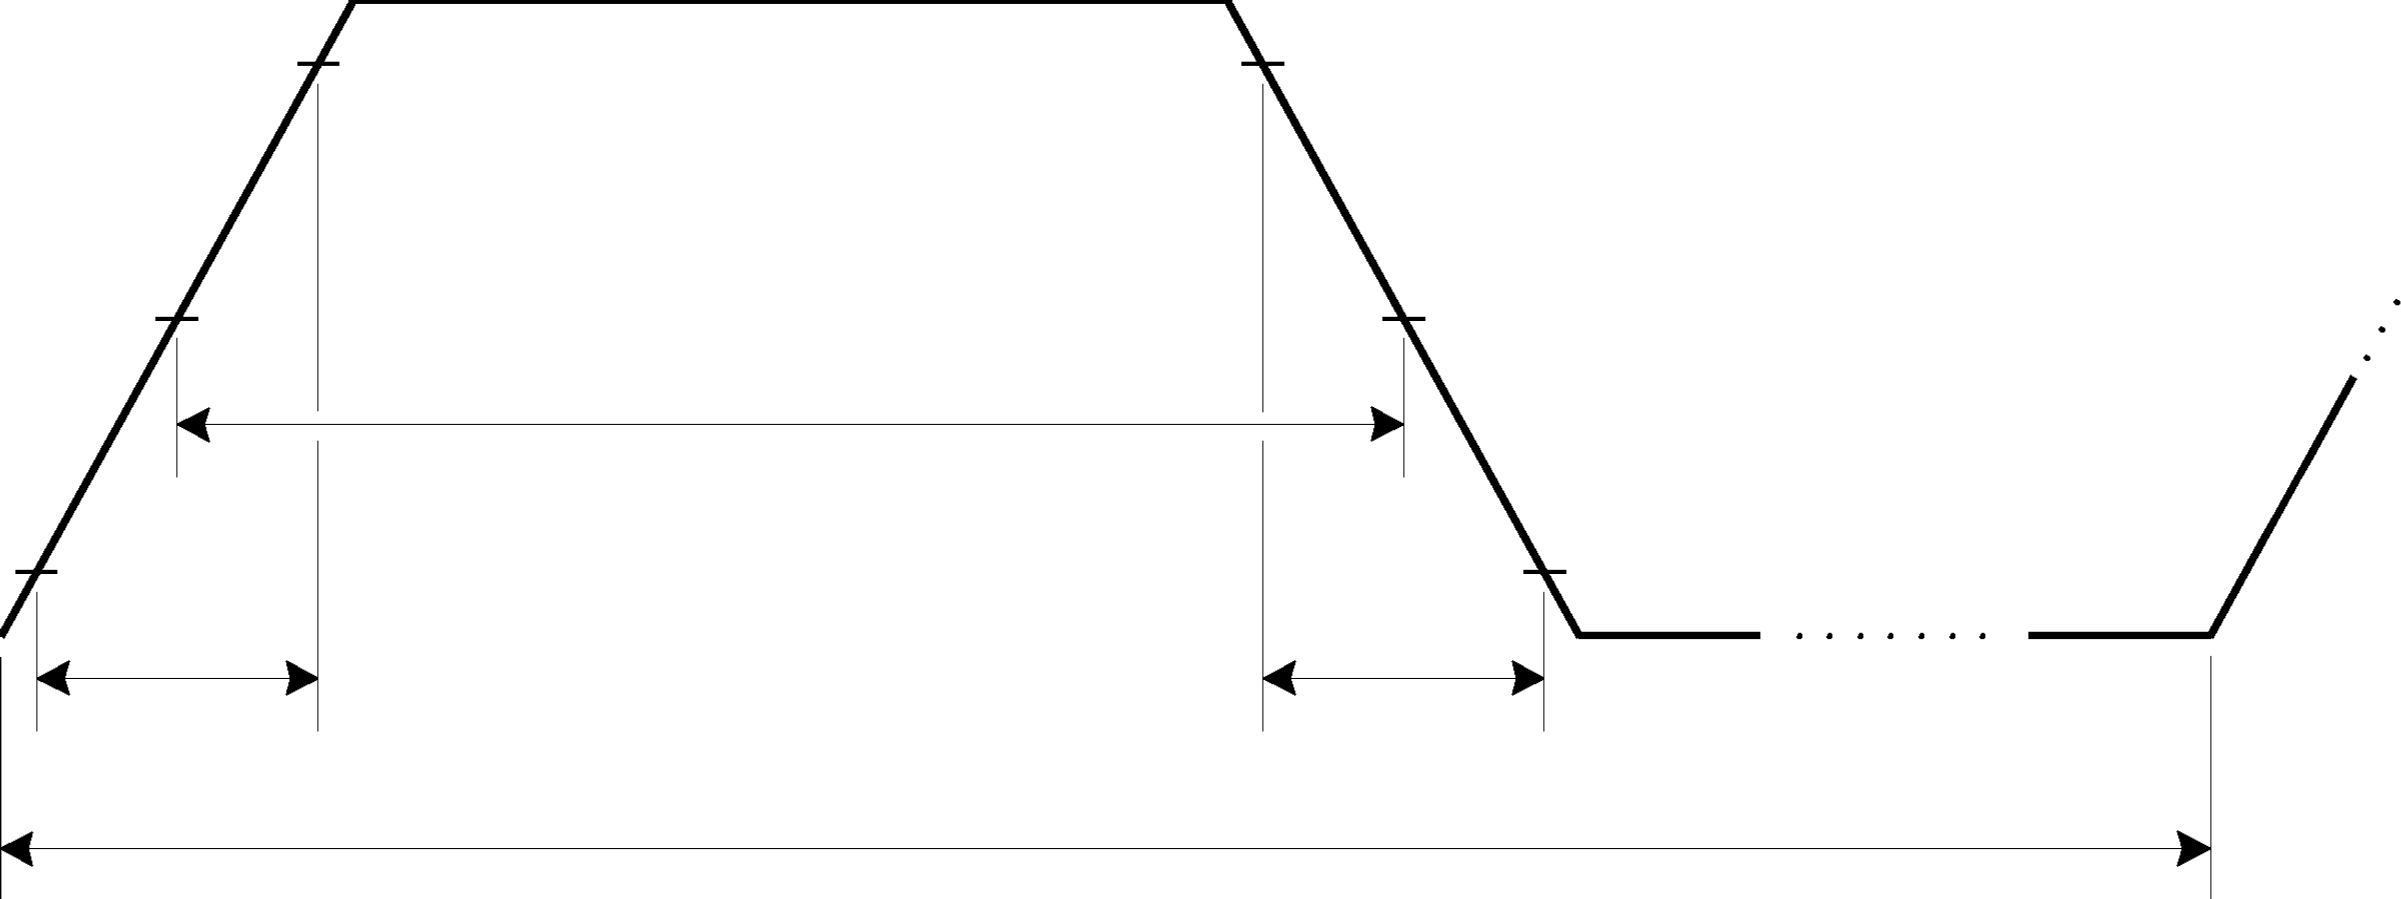

<!-- ![Alt text](../../Literatur/FPGA/Agilent%20PulsGenerator%20Handbuch%209018-04437%20-%20Pulse%20Waveforms.png)
-->

From the manual (p. 194[195] or p. 70[71]):

> The **pulse width** represents the time
> - from the 50% threshold of the rising edge of the pulse
> - to the 50% threshold of the next falling edge.
> You can vary the pulse width from 20 ns to 2000 seconds (see restrictions below).

p. 73[74]:
> **Edge Time:**
> The edge time sets each edge transition time (rising and falling) of the 
pulse. The rise time and fall time cannot be set independently — each is equal to the edge time.
> For each transition, the edge time represents the time from the 10% threshold to the 90% threshold.

We define:
- $y=f(x)$ the curve function:
$$
f(x) = \begin{cases}
    m\cdot x; x<b \\
    Y; x\in [b,c] \\
    -m\cdot x; x>c
    \end{cases}
$$
- $Y$: the height of the plateau: $Y=\max(y)$.
- $t_E$: the edge time (rise/fall) as set in the PGen (intervals $[A,B]$ and $[C,D]$).
- $W_P$: the pulse width as set in the PGen.
- $W$: the full width of the pulse-plateau (width of area with $m=0$) (interval $[b,c]$).
- $E$: the full width of the rise/fall time (width of *half* the area with $m\neq 0$) (intervals $[a,b]$ and $[c,d]$)
- $T$: the total width of the generated pulse (width of the area $y>0$): $T=E+W+E$ (interval $[a,d]$).

Together with the image from the handbook, this gives:
$$
m := \frac{(0.9Y - 0.1Y)}{t_E} = \frac{0.8Y}{t_E} = \frac{Y}{E} \\
\Rightarrow E = Y\cdot \frac{t_E}{0.8Y} = \frac{t_E}{0.8} = 1.25\cdot t_E
$$
as well as
$$
W := W_P - 2\cdot \frac{1}{2} E = W_P - 1.25t_E.
$$
In total:
$$
T = W+2E = W_P+1.25t_E
$$

In [4]:
from KeysightAgilent_3220A.pulse_emulation.pGen_pulse_class import(
    get_total_pulse_width,
    get_pulse_integral,
    get_pulse_function,
    get_pulse_integral_disc,
    get_total_pulse_integral,
    calculate_gap
) 

print(get_total_pulse_width(400, 100))

print(get_pulse_integral_disc(1000, 400, 100, 283, unit="samples"))
print(get_total_pulse_integral(400, 100, 283, unit="samples"))
print(get_total_pulse_integral(400, 100, 283, unit="samples"))

#get_total_pulse_integral(400, 100, 18)
print(
    "400/10:", get_total_pulse_width(400, 10),
    "410/10:", get_total_pulse_width(410, 10),
)

(525.0, 125.0, 275.0, 'ns')
6413.912
6413.912
6413.912
400/10: (412.5, 12.5, 387.5, 'ns') 410/10: (422.5, 12.5, 397.5, 'ns')


## mV to ADC-Counts Conversion

> Required for verification of the pulse-integrals.

Different methods:
1. Use Formula from NeuDet36  if applicable
2. Use multiple pulse measurements with different amplitude
3. Use ramp signal to get a single "Pulse" event

### (1) Use Formula from NeuDet36 if applicable

> The formula is not applicable.
$$
\text{Voltage} = \frac{\texttt{ADC\_Code} >> 4}{4096}\cdot 3\text{V}
$$

In [5]:
# def adc_to_mV_formula(adc):
#     # return (adc >> 4)/4096*3000
#     return (adc / 16)/4096*3000

# def mV_to_adc_formula(mV):
#     # return round(mV/3000*4096) << 4
#     return round((mV/3000*4096) * 16)

# mV_to_adc_formula(18)

### (2) Use multiple pulse measurements with different amplitude

Trigger-Data:
- 21 manual Triggers with increasing amplitude (1V steps)
- (W400ns, E100ns, F345Hz, A10-30mV, Inverted, no burst)
- (B4, T:8, Threshold[0]100, Trace700, Offset:adjusted.30)

Measurement 1: 2023-05-03 `testreadoutfile.bin.1`
(31/21 packages received)

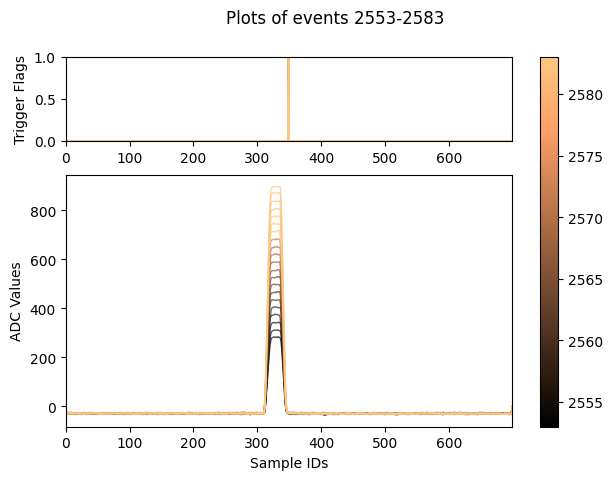

In [6]:
base_path = r"C:\Users\utrfh\WS22-23 (MA) Masterarbeit\RADC_testData\2023-05-03"

tdf = struct_conversion.DataFile(    
    base_path + r"\testreadoutfile.bin.1"
    )
tdf = data_io.make_total_dataFrame([tdf])
amplitude_list = iter(range(10,31))

tdf["Amplitude_mV"] = tdf["max"].apply(lambda e: next(amplitude_list) if e>200 else 0)
#tdf[["max", "Amplitude_mV"]]
fig = plotting.plot_rows(tdf[tdf["max"]>200])
# plotting.plot_rows(tdf.iloc[0])

529

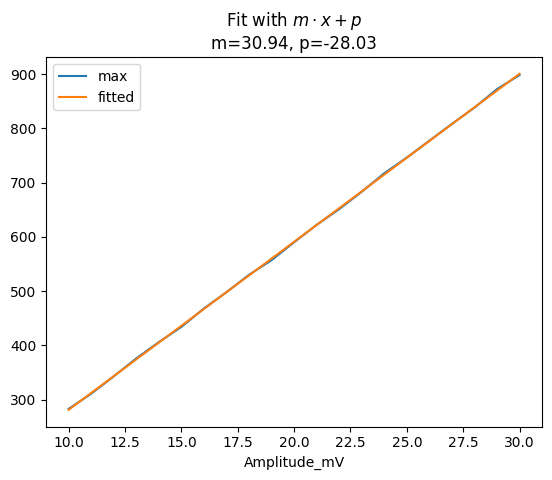

In [7]:
data = tdf[ tdf["Amplitude_mV"] > 0][["max", "Amplitude_mV"]] #.plot("max", "Amplitude_mV")

def fit_function(x, m, p):
    return m*x+p

import matplotlib.pyplot as plt
# import scipy
from scipy.optimize import curve_fit

fit = curve_fit(fit_function, xdata=data["Amplitude_mV"], ydata=data["max"])
data["fitted"] = data["Amplitude_mV"].apply(lambda row: fit_function(row, *fit[0]))
data.plot("Amplitude_mV", ["max", "fitted"])
plt.title(f"Fit with $m\\cdot x + p$\nm={fit[0][0]:.4}, p={fit[0][1]:.4}")


def mV_to_adc_fit(mV):
    return round(fit[0][0]*mV+fit[0][1])

def adc_to_mV_fit(adc):
    return (adc-fit[0][1])/fit[0][0]

mV_to_adc_fit(18)

### Method comparison

<Axes: xlabel='Amplitude_mV'>

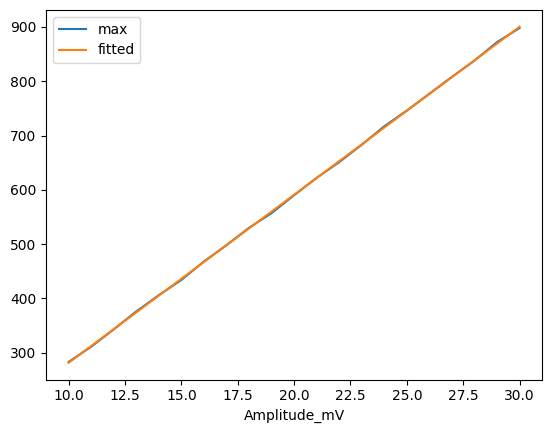

In [8]:
data.iloc[0]
# data["mV_formula"] = data["max"].apply(lambda row: adc_to_mV_formula(row))
# data["adc_formula"] = data["Amplitude_mV"].apply(lambda row: mV_to_adc_formula(row))
data.plot("Amplitude_mV", ["max", "fitted"]) # "adc_formula"])
# data.plot("max", ["Amplitude_mV", "mV_formula"])

# print(mV_to_adc_formula(adc_to_mV_formula(285)))

## Trigger verification

### Determination of optimal Threshold

In [9]:
# 18mV, 400ns, 100ns, 33, 17457, 8725, 550
height_mV = 18
height_adc= 529
width_ns = 400
edge_ns = 100

B_Time = get_total_pulse_width(width_ns, edge_ns, unit="samples")[0]

print("Integral estimate:", 0.8*B_Time*mV_to_adc_fit(height_adc))
print("Discrete summation:", get_total_pulse_integral(width_ns, edge_ns, height_adc, unit="samples"))
print("Cont integration:", get_total_pulse_integral(width_ns, edge_ns, height_adc, unit="ns"))

Integral estimate: 431402.4
Discrete summation: 11989.256000000005
Cont integration: (211600.0, 4.232, 525.0, 125.0, 275.0, (125.0, 275.0, 125.0))


In [10]:
def convert_adc_int(B_Time, adc_Threshold):
    return adc_Threshold*B_Time

def rescale_int_threshold(oldThreshold, oldB_Time, newB_Time):
    return round(oldThreshold*newB_Time/oldB_Time)


def opt_threshold_for_pulse(height_mV, width, edge_ns, unit="ns"):
    if unit == "samples":
        width = width*16 - 1.25*edge_ns

    T, E, W, u = get_total_pulse_width(width, edge_ns, unit="samples")

    thr_int_mV = 1/2*height_mV*T
    thr_int_adc= round(1/2*mV_to_adc_fit(height_mV)*T)
    return thr_int_adc, thr_int_mV

opt_threshold_for_pulse(18, 400, 100)

(8728, 297.0)

### Verification Measurements

> Using Measurements in valid range from below, compare calculation methods with captured energy values.

Use _**Measurement 1:** `2023-05-05_15-45-26_readout.bin`_

! This Measurement is **missing** one value: the list contains 21 data points to take, but the DataFrame is only 20 rows long.
Using the timestamp-Data, the best guess is that row #16 (330ns) was the last measurement in line with the others. Row #17 therefore contains the second next data point (360 and not 350).

$\Rightarrow$ Entry #17 has to be dropped from the `pulseWidths`-list.

<Axes: xlabel='pulseWidths'>

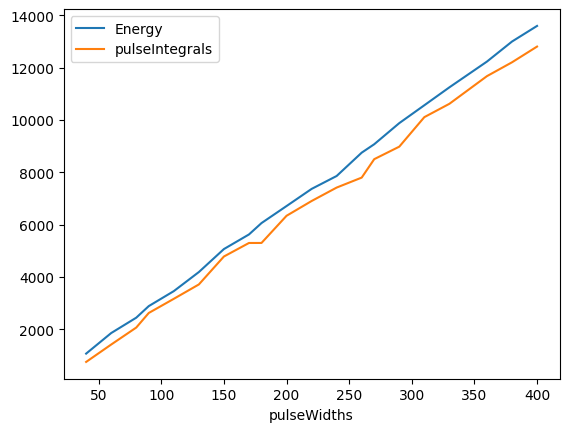

In [11]:
idf = data_io.make_total_dataFrame([
    struct_conversion.DataFile(
        r"C:\Users\utrfh\WS22-23 (MA) Masterarbeit\RADC_testData\2023-05-05\2023-05-05_15-45-26_readout.bin"
)])
pulseWidths = [round(i, -1) for i in range(40, 400+18, 18)] # Round stepwise to 10ns
pulseWidths.pop(17) # Removes entry for 350ns to adjust for missing data point.

idf["pulseWidths"] = pulseWidths

height_mV = 18
height_adc= idf["max"].mean() # 514 and not 529
edge_ns = 10
idf["pulseIntegrals"] = idf.apply(
    lambda row: get_total_pulse_integral(row["pulseWidths"], edge_ns, row["max"], unit="samples"),
    axis="columns"
)
idf.plot("pulseWidths", ["Energy", "pulseIntegrals"])
# idf.drop(irrelevant_labels + ["samples", "trigger_IDs"], axis=1)


$\Rightarrow$ I need to make small adjustements to the integral-calculation, but it works already quite well.

## Multiple Triggering Inspection

> Test limit-cases for multiple triggering for a same pulse-shaped signal

### Pulse Width

> Test if multiple triggering on a given pulse-width gets set off by widening B_Time in accordance with the pulse-width.

$$
\max(\texttt{Tracelength}) = 700\ \text{samples} \hat{=} 11200\ \text{ns}
$$

**The `B_Time` is limited to max. 31 samples.** The full pulse should therefore not exceed $31*16=496$ ns.
Start with pulsewidth at ~~400ns~~ 40ns, increase up to ~~10000ns~~ 400ns. Need around ~~30~~ 20 points:
```
round((400 - 40)/20) = 18
```
$\Rightarrow$ Steps of size 18ns (1 sample), **each step rounded to nearest 10** because the PGen cannot handle units of Nanoseconds.

**Measurement 1:** `2023-05-05_15-45-26_readout.bin`
(20/20 packages received)
- (W40-400ns, **E10**ns, F1Hz, A18mV, Inverted, Cycles1)
- (B4-33, T:default, Threshold[0]1058-6877, Trace700, Offset:adjusted.30)

**Measurement 2:** `2023-05-10_13-28-23_readout.bin`
(25/10+5+? packages received)
- (W400-600ns, E10ns, F1Hz, A18mV, Inverted, Cycles1)
- (B26-31, T:default, Threshold[0]6877-8200, Trace700, Offset:adjusted.30)

In [12]:
def get_pulse_width_threshold_df(
        pulse_min, pulse_max, step,
        edgeTime, height_mV=None, height_adc=None
        ):
    pulseWidths = [round(i, -1) for i in range(pulse_min, pulse_max+step, step)] # Round stepwise to 10ns

    if height_mV is not None and height_adc is None:
        height_adc = mV_to_adc_fit(height_mV)
    elif height_mV is None and height_adc is not None:
        height_mV = adc_to_mV_fit(height_adc)
    elif height_mV is None and height_adc is None:
        raise ValueError

    B_Times = []
    pulseIntegrals = []
    optThresholds = []
    pulseTotalWidths= []
    for pw in pulseWidths:
        B_Times.append(get_total_pulse_width(pw, edgeTime, unit="samples")[0])
        pulseIntegrals.append(get_total_pulse_integral(pw, edgeTime, height_adc, unit="samples"))
        optThresholds.append(opt_threshold_for_pulse(height_mV, pw, edgeTime)[0])
        pulseTotalWidths.append(get_total_pulse_width(pw, edgeTime, unit="ns")[0])

    empiricalThresholds = [1090]
    for i,bt in enumerate(B_Times):
        # print(i,bt, Thresholds[i])
        if i > 0:
            empiricalThresholds.append(rescale_int_threshold(empiricalThresholds[i-1], B_Times[i-1], B_Times[i]))
        if bt > 31:
            B_Times[i] = 31
            optThresholds[i] = opt_threshold_for_pulse(height_mV, 31, edgeTime, unit="samples")[0]


    df = pd.DataFrame({
        "pulseWidths": pulseWidths,
        "pulseTotalWidths": pulseTotalWidths,
        "pulseIntegrals": pulseIntegrals,
        "B_Times": B_Times,
        "empiricalThresholds": empiricalThresholds,
        "optThresholds": optThresholds,
        })
    df["threshRatio"] = df["pulseIntegrals"] / df["optThresholds"]
    return df

In [13]:
edgeTime = 10 # ns
height_mV = 18  # mV
height_adc = mV_to_adc_fit(height_mV)
# print(list(pulseWidths))
point_df_1 = get_pulse_width_threshold_df(40, 400, 18, edgeTime, height_mV, height_adc)
point_df_2 = get_pulse_width_threshold_df(400, 700, 20, edgeTime, height_mV, height_adc)

# Warning: this does not adjust the threshRatio!
point_df_2["optThresholds"] = point_df_2["optThresholds"].apply(lambda x: min(x, 8200))

point_df_1
point_df_2#[["pulseWidths", "B_Times", "optThresholds"]]

,pulseWidths,pulseTotalWidths,pulseIntegrals,B_Times,empiricalThresholds,optThresholds,threshRatio
0,400,412.5,12738.32,26,1090,6877,1.852308
1,420,432.5,12653.68,28,1174,7406,1.708571
2,440,452.5,14325.32,29,1216,7670,1.867708
3,460,472.5,14854.32,30,1258,7935,1.872000
4,480,492.5,15383.32,31,1300,8200,1.876015
5,500,512.5,15087.08,31,1384,8200,1.782500
6,520,532.5,16970.32,31,1518,8200,2.005000
7,540,552.5,17499.32,31,1714,8200,2.067500
8,560,572.5,18028.32,31,1990,8200,2.130000
9,580,592.5,17520.48,31,2439,8200,2.070000


The Measurements used `point_df_1` and `point_df_2`.

Inspecting the data:

(44, (284, 148), (328, 4))


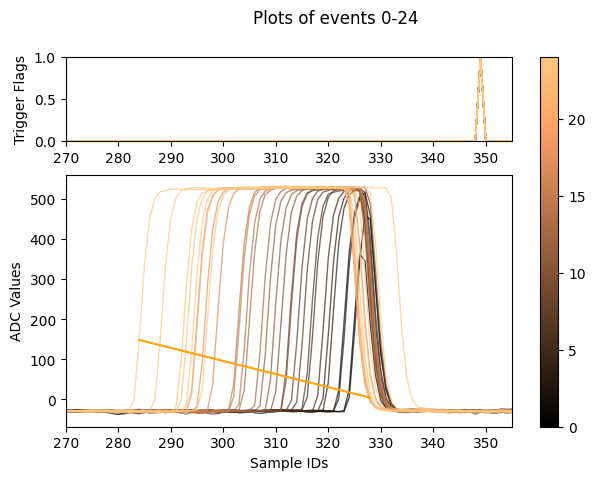

,Number,Event_ID,Energy,Seconds,trigger_IDs,samples
24,5,4,15057,189,[349],"[-29, -29, -32, -30, -31, -31, -30, -32, -30, ..."
27,13,12,15048,459,[349],"[-29, -28, -31, -30, -29, -29, -28, -29, -30, ..."
30,16,15,15427,488,[349],"[-30, -30, -31, -28, -30, -29, -28, -27, -29, ..."
31,17,16,15706,501,[349],"[-29, -30, -31, -30, -30, -29, -29, -27, -30, ..."
32,18,17,17164,516,[349],"[-32, -32, -30, -31, -30, -31, -29, -31, -32, ..."
33,19,18,17218,532,[349],"[-30, -31, -31, -30, -29, -29, -30, -30, -27, ..."
36,22,21,16086,574,[349],"[-28, -29, -31, -28, -29, -27, -29, -28, -30, ..."
39,25,24,15276,596,[349],"[-30, -29, -29, -27, -28, -29, -28, -29, -29, ..."


In [14]:
pdf = data_io.make_total_dataFrame([
    struct_conversion.DataFile(
        r"C:\Users\utrfh\WS22-23 (MA) Masterarbeit\RADC_testData\2023-05-05\2023-05-05_15-45-26_readout.bin"
    ),
    struct_conversion.DataFile(
        r"C:\Users\utrfh\WS22-23 (MA) Masterarbeit\RADC_testData\2023-05-10\2023-05-10_13-28-23_readout.bin"
    )
    ])
pdf.drop_duplicates(subset="Seconds", keep='first', inplace=True)


fitting_df = pdf[pdf["trigger_count"] == 1]
fig = plotting.plot_rows(fitting_df, xlim=(270,355))

gaps = fitting_df["samples"].apply(calculate_gap)
widest_gap = max(gaps, key=lambda x: x[0])
print(widest_gap) #gaps)
ax = fig.axes[1]
x = (widest_gap[1][0], widest_gap[2][0])
y = (widest_gap[1][1], widest_gap[2][1])
ax.plot(x, y, color="orange")
plt.show()
# gaps.apply(lambda x: x[0]).hist(bins=14)
fitting_df[ gaps.apply(lambda x: x[0] > 31 )].drop(irrelevant_labels, axis="columns")

We note that wider pulses may still trigger only once, but the Energy-value will be false, as it stays around $15$-$17$ thousand instead of continuing to increase.

25     (33, (299, 37), (332, 26))
28     (34, (300, 27), (334, 48))
34     (40, (299, 41), (339, 59))
37    (42, (298, 120), (340, 63))
40    (45, (297, 100), (342, 29))
43      (47, (295, 67), (342, 2))
Name: samples, dtype: object


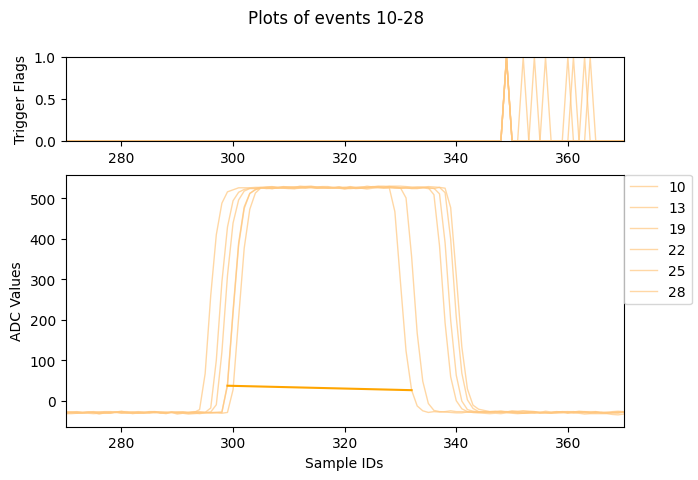

,Number,Event_ID,Energy,Seconds,trigger_IDs,samples
25,11,10,16130,420,"[349, 354]","[-29, -29, -28, -28, -28, -29, -27, -27, -27, ..."
28,14,13,15668,482,"[349, 356]","[-30, -31, -31, -31, -30, -32, -31, -31, -30, ..."
34,20,19,16250,548,"[349, 361]","[-26, -27, -27, -28, -29, -31, -30, -30, -31, ..."
37,23,22,16872,584,"[349, 360]","[-31, -31, -29, -27, -27, -29, -27, -27, -27, ..."
40,26,25,17048,609,"[349, 352, 364]","[-30, -32, -30, -31, -29, -31, -30, -30, -29, ..."
43,29,28,17254,619,"[349, 363]","[-29, -29, -30, -30, -30, -32, -31, -29, -30, ..."


In [15]:
too_large_df = pdf[pdf["trigger_count"] > 1]
gaps = too_large_df["samples"].apply(calculate_gap)
print(gaps)

fig = plotting.plot_rows(too_large_df, xlim=(270,370))

smallest_gap = min(gaps, key=lambda x: x[0])
ax = fig.axes[1]
x = (smallest_gap[1][0], smallest_gap[2][0])
y = (smallest_gap[1][1], smallest_gap[2][1])
ax.plot(x, y, color="orange")
plt.show()


too_large_df.drop(
    labels=["Channel_number", "Type", "Rest",
            "min", "max", "trigger_count",
            "Multiplicity", "Trigger_info",
            "Subsecs"],
    axis="columns"
)


A good sign is that the smallest gaps belonging to pulses that caused multiple triggering are wider than the maximal `B_Time`.

### Testing the limit on reliability

> Use the maximum available settings and send a lot of pulses.

23    14633
24    15057
27    15048
30    15427
31    15706
Name: Energy, dtype: int64

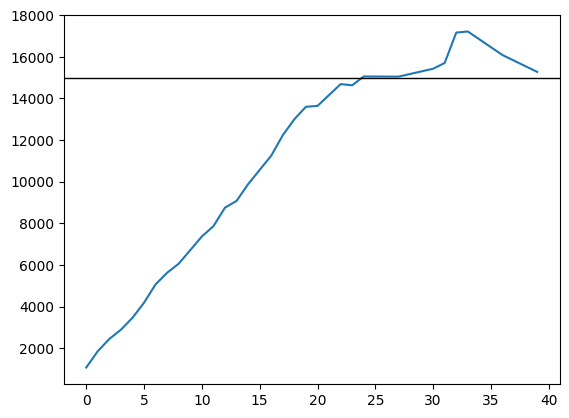

In [16]:
fitting_df["Energy"].plot()
plt.axhline(15000, color="black", linewidth=1)

fitting_df["Energy"].iloc[22:27]

Thus, the point as of which curve-growth is no longer linear is at $E\approx 15000$, given by the entry with `index == 24`.
Using this as a starting point, we get:

In [17]:

fitting_df[fitting_df.index == 24].drop(irrelevant_labels, axis=1)

,Number,Event_ID,Energy,Seconds,trigger_IDs,samples
24,5,4,15057,189,[349],"[-29, -29, -32, -30, -31, -31, -30, -32, -30, ..."


This means that it is part of the second measurement/file, corresponding to:
```
4	480	492.5	15383.32	31	8200
```

Now measuring 1000 Events with the following parameters:

**Measurement 1:** `2023-05-10_16-47-46_readout.bin`
(1116/1000 packages received)
- (W480ns, E10ns, F1kHz, A18mV, Inverted, Cycles1000)
- (B31, T:default, Threshold[0]8200, Trace700, Offset:adjusted.30)

**Measurement 2:** `2023-05-10_16-53-00_readout.bin`
(1129/1000 packages received)
- (W480ns, E10ns, F1kHz, A18mV, Inverted, Cycles1000)
- (B31, T:default, Threshold[0]14500, Trace700, Offset:adjusted.30)

**Measurement 3:** `2023-05-10_16-47-46_readout.bin`
(1129/1000 packages received)

(Lowering to a width of 450)
- (W450ns, E10ns, F1kHz, A18mV, Inverted, Cycles1000)
- (B31, T:default, Threshold[0]14500, Trace700, Offset:adjusted.30)

**Measurement 4:** `2023-05-10_16-47-46_readout.bin`
(1000/1000 packages received)

(Lowering to a width of 400)
- (W400ns, E10ns, F1kHz, A18mV, Inverted, Cycles1000)
- (B31, T:default, Threshold[0]8200, Trace700, Offset:adjusted.30)

**Measurement 5:** `2023-05-10_17-10-21_readout.bin`
(1014/1000 packages received)

(Lowering to a width of 430)
- (W430ns, E10ns, F1kHz, A18mV, Inverted, Cycles1000)
- (B31, T:default, Threshold[0]8200, Trace700, Offset:adjusted.30)

**Measurement 6:** `2023-05-10_17-18-44_readout.bin`
(1003/1000 packages received)

(Lowering to a width of 420)
- (W420ns, E10ns, F1kHz, A18mV, Inverted, Cycles1000)
- (B31, T:default, Threshold[0]8200, Trace700, Offset:adjusted.30)

,Number,Event_ID,Energy,Seconds,trigger_IDs,samples
3,4,3,16021,52,"[349, 354]","[-30, -30, -28, -28, -30, -29, -28, -28, -29, ..."
4,5,4,14928,52,"[344, 349]","[-29, -28, -28, -29, -28, -29, -31, -31, -27, ..."
8,9,8,15811,52,"[349, 355]","[-27, -28, -29, -29, -30, -30, -28, -28, -30, ..."
9,10,9,14754,52,"[343, 349]","[-28, -28, -30, -30, -31, -30, -31, -29, -29, ..."
18,19,18,16189,52,"[349, 354]","[-29, -30, -31, -30, -32, -31, -29, -30, -30, ..."
...,...,...,...,...,...,...
1106,83,1106,15002,53,"[343, 349]","[-31, -31, -31, -31, -30, -29, -30, -30, -30, ..."
1109,86,1109,16372,53,"[349, 353]","[-32, -31, -31, -29, -30, -31, -31, -31, -32, ..."
1110,87,1110,15236,53,"[345, 349]","[-30, -31, -31, -31, -32, -30, -31, -32, -31, ..."
1112,89,1112,16312,53,"[349, 354]","[-30, -31, -31, -32, -34, -33, -33, -31, -31, ..."


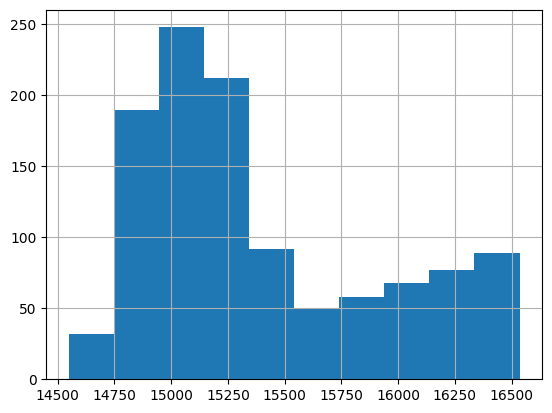

In [18]:
kdf = data_io.make_total_dataFrame([
    struct_conversion.DataFile(
        r"C:\Users\utrfh\WS22-23 (MA) Masterarbeit\RADC_testData\2023-05-10\2023-05-10_16-47-46_readout.bin"
    ),
    ])
kdf["Energy"].hist()
kdf[ kdf["trigger_count"] > 1].drop(irrelevant_labels, axis=1)

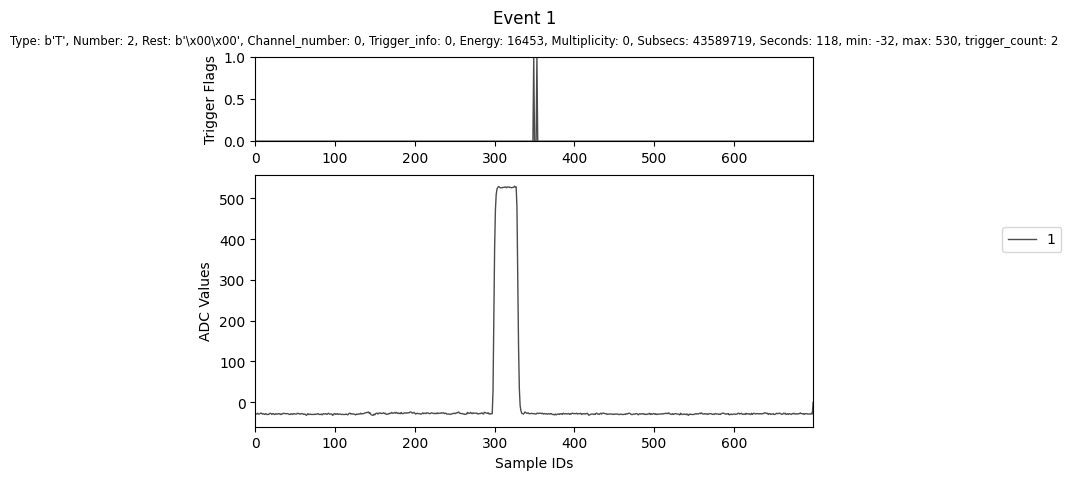

In [19]:
k2df = data_io.make_total_dataFrame([
    struct_conversion.DataFile(
        r"C:/Users/utrfh/WS22-23 (MA) Masterarbeit/RADC_testData\2023-05-10\2023-05-10_16-53-00_readout.bin"
    ),
    ])
k2df[ k2df["trigger_count"] > 1].drop(irrelevant_labels, axis=1)

fig = plotting.plot_rows(k2df[k2df["trigger_count"] > 1].iloc[0])


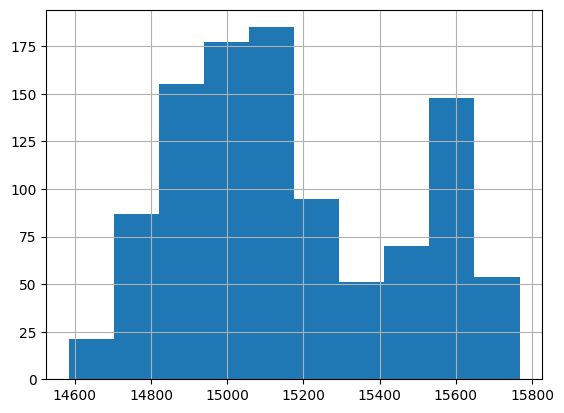

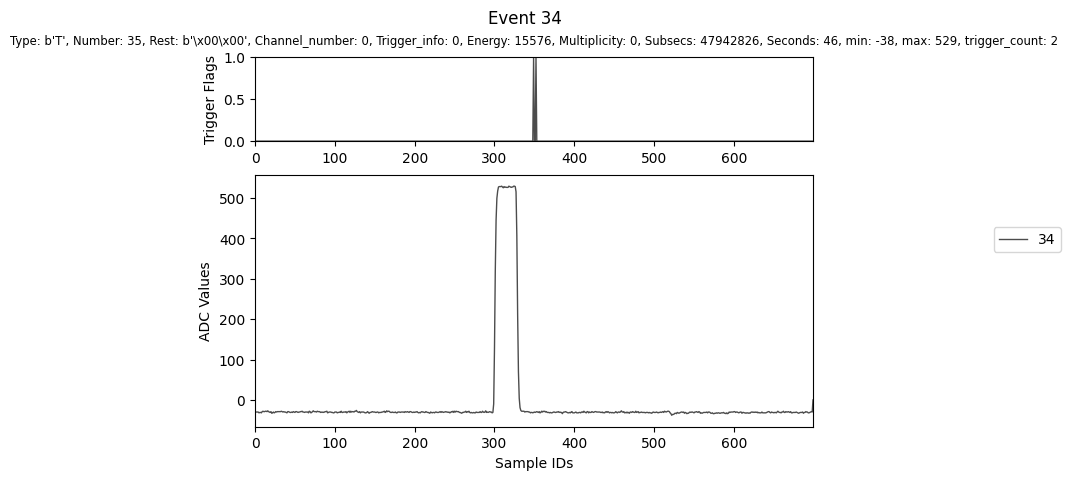

In [20]:
k3df = data_io.make_total_dataFrame([
    struct_conversion.DataFile(
        r"C:/Users/utrfh/WS22-23 (MA) Masterarbeit/RADC_testData\2023-05-10\2023-05-10_17-07-45_readout.bin"
    ),
    ])
k3df[ k3df["trigger_count"] > 1].drop(irrelevant_labels, axis=1)
k3df["Energy"].hist()

fig = plotting.plot_rows(k3df[k3df["trigger_count"] > 1].iloc[0])


In [21]:
k4df = data_io.make_total_dataFrame([
    struct_conversion.DataFile(
        r"C:/Users/utrfh/WS22-23 (MA) Masterarbeit/RADC_testData\2023-05-10\2023-05-10_17-10-21_readout.bin"
    ),
    ])
k4df[ k4df["trigger_count"] > 1].drop(irrelevant_labels, axis=1)
# k4df["Energy"].hist()

# fig = plotting.plot_rows(k4df[k4df["trigger_count"] > 1].iloc[0])


,Number,Event_ID,Energy,Seconds,trigger_IDs,samples


In [22]:
k5df = data_io.make_total_dataFrame([
    struct_conversion.DataFile(
        r"C:/Users/utrfh/WS22-23 (MA) Masterarbeit/RADC_testData\2023-05-10\2023-05-10_17-10-21_readout.bin"
    ),
    ])
k5df[ k5df["trigger_count"] > 1].drop(irrelevant_labels, axis=1)
# k5df["Energy"].hist()

# fig = plotting.plot_rows(k5df[k5df["trigger_count"] > 1].iloc[0])


,Number,Event_ID,Energy,Seconds,trigger_IDs,samples
